In [1]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 70.1 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


## Local Inference on GPU
Model page: https://huggingface.co/facebook/sam3

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/facebook/sam3)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

The model you are trying to use is gated. Please make sure you have access to it by visiting the model page.To run inference, either set HF_TOKEN in your environment variables/ Secrets or run the following cell to login. 🤗

In [3]:
from huggingface_hub import login
login()

In [4]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("mask-generation", model="facebook/sam3")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/685 [00:00<?, ?it/s]

processor_config.json: 0.00B [00:00, ?B/s]

In [5]:
# Load model directly
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("facebook/sam3")
model = AutoModel.from_pretrained("facebook/sam3")

tokenizer_config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

Using device: cuda


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Original image size: (5300, 2976)
Pass 1 found 1 objects
Pass 1 best score: 0.9570793509483337
Pass 1 best box: [2297, 68, 3691, 1789]
Crop box: [2137, 0, 3851, 1949]
Crop size: (1714, 1949)
Pass 2 found 1 objects
Pass 2 best score: 0.956673800945282
Pass 2 best box (crop coords): [156, 60, 1579, 1780]
Saved:
/content/final_mask.png
/content/final_overlay.png
/content/refinement_crop.png


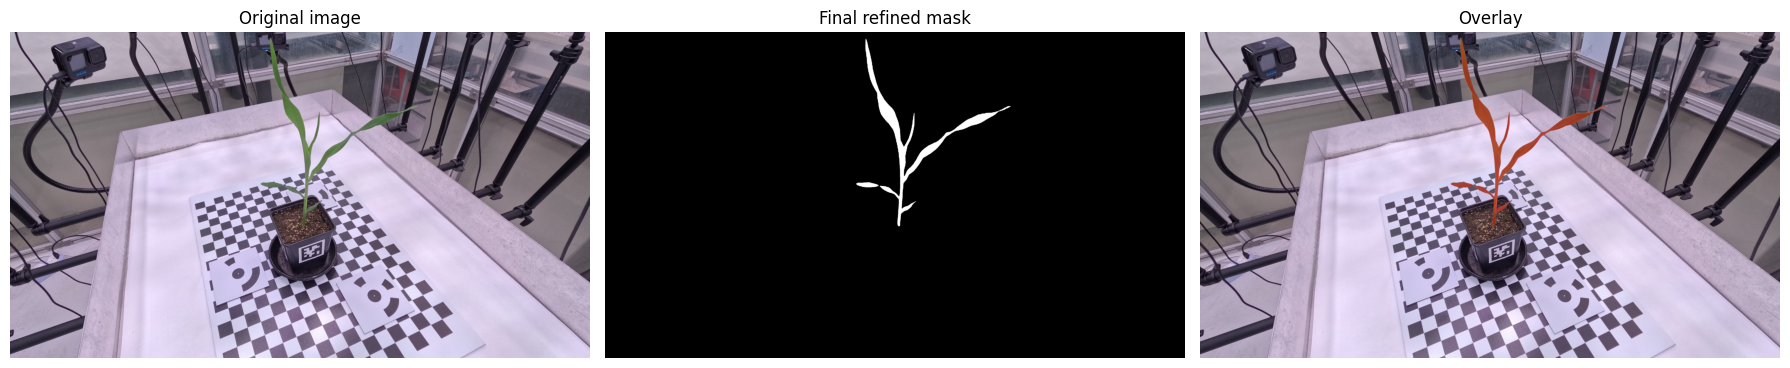

In [25]:
# !pip install -q transformers torch pillow matplotlib numpy

from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = Sam3Model.from_pretrained("facebook/sam3").to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")

image_path = "/content/GX010009_20250825_070502_1880_0.jpg"
text_prompt = "plant"

# ---------- helpers ----------

def run_sam_text(image, text, threshold=0.5, mask_threshold=0.5):
    inputs = processor(images=image, text=text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        mask_threshold=mask_threshold,
        target_sizes=inputs["original_sizes"].tolist()
    )[0]

    return results

def select_best_result(results):
    if len(results["scores"]) == 0:
        return None

    # results["scores"] may already be torch tensor
    if isinstance(results["scores"], torch.Tensor):
        best_idx = int(torch.argmax(results["scores"]).item())
    else:
        best_idx = int(np.argmax(results["scores"]))

    best = {
        "idx": best_idx,
        "score": float(results["scores"][best_idx]),
        "box": results["boxes"][best_idx],
        "mask": results["masks"][best_idx],
    }
    return best

def to_numpy_mask(mask_tensor):
    if isinstance(mask_tensor, torch.Tensor):
        return mask_tensor.detach().cpu().numpy().astype(np.uint8)
    return np.array(mask_tensor).astype(np.uint8)

def to_numpy_box(box_tensor):
    if isinstance(box_tensor, torch.Tensor):
        box = box_tensor.detach().cpu().numpy()
    else:
        box = np.array(box_tensor)
    return box.astype(int)

def expand_box_xyxy(box, image_width, image_height, pad=128):
    x1, y1, x2, y2 = box.tolist()
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(image_width, x2 + pad)
    y2 = min(image_height, y2 + pad)
    return [x1, y1, x2, y2]

def overlay_mask_on_image(image_pil, mask_np, alpha=0.45):
    image_rgba = image_pil.convert("RGBA")
    overlay = Image.new("RGBA", image_pil.size, (255, 0, 0, 0))

    mask_img = Image.fromarray((mask_np > 0).astype(np.uint8) * 255)
    overlay_alpha = mask_img.point(lambda p: int(p * alpha))
    overlay.putalpha(overlay_alpha)

    composed = Image.alpha_composite(image_rgba, overlay)
    return composed

# ---------- load image ----------

image = Image.open(image_path).convert("RGB")
W, H = image.size
print("Original image size:", image.size)

# ---------- pass 1: full image ----------

results_full = run_sam_text(
    image=image,
    text=text_prompt,
    threshold=0.5,
    mask_threshold=0.5
)

print(f"Pass 1 found {len(results_full['masks'])} objects")

best_full = select_best_result(results_full)
if best_full is None:
    raise RuntimeError("No objects found in pass 1.")

full_box = to_numpy_box(best_full["box"])
full_mask = to_numpy_mask(best_full["mask"])

print("Pass 1 best score:", best_full["score"])
print("Pass 1 best box:", full_box.tolist())

# ---------- crop around best detection ----------

crop_box = expand_box_xyxy(full_box, W, H, pad=160)
x1, y1, x2, y2 = crop_box
crop = image.crop((x1, y1, x2, y2))

print("Crop box:", crop_box)
print("Crop size:", crop.size)

# ---------- pass 2: rerun on crop ----------

results_crop = run_sam_text(
    image=crop,
    text=text_prompt,
    threshold=0.5,
    mask_threshold=0.5
)

print(f"Pass 2 found {len(results_crop['masks'])} objects")

best_crop = select_best_result(results_crop)

if best_crop is None:
    print("No objects found in crop pass; falling back to pass 1 mask.")
    refined_mask_full = full_mask
else:
    crop_mask = to_numpy_mask(best_crop["mask"])
    crop_box_inner = to_numpy_box(best_crop["box"])

    print("Pass 2 best score:", best_crop["score"])
    print("Pass 2 best box (crop coords):", crop_box_inner.tolist())

    # paste crop mask back into full-image coordinates
    refined_mask_full = np.zeros((H, W), dtype=np.uint8)
    refined_mask_full[y1:y2, x1:x2] = crop_mask

# ---------- save outputs ----------

mask_png = Image.fromarray((refined_mask_full > 0).astype(np.uint8) * 255)
overlay_png = overlay_mask_on_image(image, refined_mask_full, alpha=0.45)

mask_path = "/content/final_mask.png"
overlay_path = "/content/final_overlay.png"
crop_path = "/content/refinement_crop.png"

mask_png.save(mask_path)
overlay_png.save(overlay_path)
crop.save(crop_path)

print("Saved:")
print(mask_path)
print(overlay_path)
print(crop_path)

# ---------- preview ----------

fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(1, 3, 1)
ax1.imshow(image)
ax1.set_title("Original image")
ax1.axis("off")

ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(mask_png, cmap="gray")
ax2.set_title("Final refined mask")
ax2.axis("off")

ax3 = fig.add_subplot(1, 3, 3)
ax3.imshow(overlay_png)
ax3.set_title("Overlay")
ax3.axis("off")

plt.tight_layout()
plt.show()


In [29]:
# !pip install -q transformers torch pillow numpy

from transformers import Sam3Processor, Sam3Model
import torch
from PIL import Image
import numpy as np
from pathlib import Path

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = Sam3Model.from_pretrained("facebook/sam3").to(device)
processor = Sam3Processor.from_pretrained("facebook/sam3")

# ======================
# SETTINGS
# ======================

input_dir = "/content/images"        # folder with original images
output_dir = "/content/masks"        # where masks will be saved

text_prompt = "plant"
threshold = 0.5
mask_threshold = 0.5
crop_padding = 160

# Create output folder if needed
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

input_dir = Path(input_dir)

# ======================
# HELPERS
# ======================

def run_sam_text(image):
    inputs = processor(images=image, text=text_prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_instance_segmentation(
        outputs,
        threshold=threshold,
        mask_threshold=mask_threshold,
        target_sizes=inputs["original_sizes"].tolist()
    )[0]

    return results


def select_best_result(results):
    if len(results["scores"]) == 0:
        return None

    if isinstance(results["scores"], torch.Tensor):
        idx = int(torch.argmax(results["scores"]).item())
    else:
        idx = int(np.argmax(results["scores"]))

    return {
        "box": results["boxes"][idx],
        "mask": results["masks"][idx],
    }


def to_numpy_mask(mask):
    if isinstance(mask, torch.Tensor):
        return mask.cpu().numpy().astype(np.uint8)
    return np.array(mask).astype(np.uint8)


def to_numpy_box(box):
    if isinstance(box, torch.Tensor):
        return box.cpu().numpy().astype(int)
    return np.array(box).astype(int)


def expand_box(box, W, H, pad):
    x1, y1, x2, y2 = box
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(W, x2 + pad)
    y2 = min(H, y2 + pad)
    return [x1, y1, x2, y2]


# ======================
# PROCESS ONE IMAGE
# ======================

def process_image(image_path):

    try:
        image = Image.open(image_path).convert("RGB")
    except:
        print("Failed:", image_path)
        return

    W, H = image.size

    # First pass
    results = run_sam_text(image)
    best = select_best_result(results)

    if best is None:
        print("No detection:", image_path.name)
        return

    box = to_numpy_box(best["box"])
    mask_full = to_numpy_mask(best["mask"])

    # Crop refinement
    x1, y1, x2, y2 = expand_box(box, W, H, crop_padding)
    crop = image.crop((x1, y1, x2, y2))

    results_crop = run_sam_text(crop)
    best_crop = select_best_result(results_crop)

    if best_crop is None:
        final_mask = mask_full
    else:
        crop_mask = to_numpy_mask(best_crop["mask"])
        final_mask = np.zeros((H, W), dtype=np.uint8)
        final_mask[y1:y2, x1:x2] = crop_mask

    mask_img = Image.fromarray((final_mask > 0).astype(np.uint8) * 255)

    output_path = output_dir / f"{image_path.stem}_mask_sam3.png"
    mask_img.save(output_path)

    print("Saved:", output_path.name)


# ======================
# FIND IMAGES
# ======================

extensions = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"}

images = [
    p for p in input_dir.iterdir()
    if p.suffix.lower() in extensions
]

print("Found", len(images), "images")

# ======================
# RUN
# ======================

for img in images:
    process_image(img)

print("Finished.")


Using device: cuda


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Found 42 images


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Saved: GX010051_20250818_183002_0001_3_mask_sam3.png
Saved: GX010141_20250825_070502_1880_15_mask_sam3.png
Saved: GX010141_20250818_183002_0001_15_mask_sam3.png
Saved: GX010062_20250818_183002_0001_5_mask_sam3.png
Saved: GX010067_20250825_070502_1880_6_mask_sam3.png
Saved: GX010062_20250825_070502_1880_5_mask_sam3.png
Saved: GX010319_20250818_183002_0001_20_mask_sam3.png
Saved: GX010078_20250818_183002_0001_9_mask_sam3.png
Saved: GX010070_20250818_183002_0001_8_mask_sam3.png
Saved: GX010068_20250818_183002_0001_7_mask_sam3.png
Saved: GX010089_20250825_070502_1880_11_mask_sam3.png
Saved: GX010046_20250818_183002_0001_2_mask_sam3.png
Saved: GX010148_20250825_070503_1880_16_mask_sam3.png
Saved: GX010009_20250818_183002_0001_0_mask_sam3.png
Saved: GX010134_20250825_070502_1880_14_mask_sam3.png
Saved: GX010078_20250825_070502_1880_9_mask_sam3.png
Saved: GX010148_20250818_183003_0001_16_mask_sam3.png
Saved: GX010059_20250825_070502_1880_4_mask_sam3.png
Saved: GX010208_20250818_183002_0001_18

In [30]:
import shutil
from google.colab import files

# Create a zip archive of the 'masks' directory
output_filename = 'masks_archive'
shutil.make_archive(output_filename, 'zip', '/content/masks')

# Provide a download link for the zip file
files.download(output_filename + '.zip')

print(f"All masks from '/content/masks' have been compressed into '{output_filename}.zip' and are ready for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All masks from '/content/masks' have been compressed into 'masks_archive.zip' and are ready for download.


In [31]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import os

# Re-using output_dir and input_dir from previously executed cell (Kw_JLCIM37Bn)
# (Ensure these paths are correct based on your previous processing)
output_dir = Path("/content/masks")
input_dir = Path("/content/images")

# Define output directory for compressed overlays
overlay_output_dir = Path("/content/masks_overlays_compressed")
overlay_output_dir.mkdir(parents=True, exist_ok=True)

print(f"Saving compressed overlays to: {overlay_output_dir}")

def save_overlay_cv2(image_pil, mask_np, out_path):
    """
    Overlays a mask onto an image and saves the compressed result using OpenCV.
    Uses green for the mask color and JPEG quality 50, matching the reference.
    """
    # Convert PIL Image to OpenCV format (RGB to BGR)
    image_rgb = np.array(image_pil)
    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    overlay = image_bgr.copy()

    # Apply green mask to the overlay where mask_np is True (non-zero)
    # The reference uses green channel for the mask
    overlay[mask_np > 0, 1] = 255  # Set green channel to max for masked pixels

    # Blend original image and overlay with specified alpha values
    blended = cv2.addWeighted(image_bgr, 0.70, overlay, 0.30, 0)

    # Save as heavily compressed JPEG with quality 50
    cv2.imwrite(str(out_path), blended, [cv2.IMWRITE_JPEG_QUALITY, 50])

# Collect image files and their corresponding mask files
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
processed_images = [
    p for p in input_dir.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
]
processed_images.sort() # Ensure consistent order

if not processed_images:
    print(f"No images found in: {input_dir}. Skipping overlay generation.")
else:
    for img_file in processed_images:
        # Load original image
        original_image_path = input_dir / img_file.name
        try:
            image_pil = Image.open(original_image_path).convert("RGB")
        except Exception as e:
            print(f"Could not load original image {original_image_path.name}: {e}")
            continue

        # Load corresponding mask (assuming it was saved by the previous step)
        mask_name = f"{img_file.stem}_mask_sam3.png"
        mask_path = output_dir / mask_name

        if not mask_path.exists():
            print(f"Mask not found for {img_file.name} at {mask_path}. Skipping overlay for this image.")
            continue

        try:
            mask_img = Image.open(mask_path).convert("L") # Load mask as grayscale
            mask_np = np.array(mask_img) > 0 # Convert to boolean mask (True for masked pixels)
        except Exception as e:
            print(f"Could not load mask {mask_name}: {e}")
            continue

        # Define output path for the overlay
        overlay_filename = f"{img_file.stem}_overlay_sam3.jpg"
        overlay_out_path = overlay_output_dir / overlay_filename

        # Save the overlay
        save_overlay_cv2(image_pil, mask_np, overlay_out_path)
        print(f"Saved overlay: {overlay_out_path.name}")

    print("Finished generating overlays.")

Saving compressed overlays to: /content/masks_overlays_compressed


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Saved overlay: GX010009_20250818_183002_0001_0_overlay_sam3.jpg
Saved overlay: GX010009_20250825_070502_1880_0_overlay_sam3.jpg
Saved overlay: GX010030_20250818_183002_0001_1_overlay_sam3.jpg
Saved overlay: GX010030_20250825_070502_1880_1_overlay_sam3.jpg
Saved overlay: GX010046_20250818_183002_0001_2_overlay_sam3.jpg
Saved overlay: GX010046_20250825_070502_1880_2_overlay_sam3.jpg
Saved overlay: GX010051_20250818_183002_0001_3_overlay_sam3.jpg
Saved overlay: GX010051_20250825_070502_1880_3_overlay_sam3.jpg
Saved overlay: GX010059_20250818_183002_0001_4_overlay_sam3.jpg
Saved overlay: GX010059_20250825_070502_1880_4_overlay_sam3.jpg
Saved overlay: GX010062_20250818_183002_0001_5_overlay_sam3.jpg
Saved overlay: GX010062_20250825_070502_1880_5_overlay_sam3.jpg
Saved overlay: GX010067_20250818_183002_0001_6_overlay_sam3.jpg
Saved overlay: GX010067_20250825_070502_1880_6_overlay_sam3.jpg
Saved overlay: GX010068_20250818_183002_0001_7_overlay_sam3.jpg
Saved overlay: GX010068_20250825_070502_

In [ ]:
import shutil
from google.colab import files
from pathlib import Path
import os

overlay_output_dir = Path("/content/masks_overlays_compressed")

# Filter overlays based on name pattern
overlays_0001 = []
overlays_1880 = []

for overlay_file in overlay_output_dir.iterdir():
    if overlay_file.is_file() and overlay_file.suffix.lower() == '.jpg':
        if "0001" in overlay_file.name:
            overlays_0001.append(overlay_file)
        elif "1880" in overlay_file.name:
            overlays_1880.append(overlay_file)

# Function to create a zip and download
def create_and_download_zip(file_list, zip_name):
    if not file_list:
        print(f"No files found for {zip_name}. Skipping zip creation.")
        return

    # Create a temporary directory for zipping
    temp_dir = Path(f"/content/temp_{zip_name}")
    temp_dir.mkdir(parents=True, exist_ok=True)

    for f_path in file_list:
        shutil.copy(f_path, temp_dir)

    output_zip_path = Path(f"/content/{zip_name}")
    shutil.make_archive(str(output_zip_path), 'zip', temp_dir)

    files.download(str(output_zip_path) + '.zip')
    print(f"Created and downloaded: {zip_name}.zip")

    # Clean up the temporary directory
    shutil.rmtree(temp_dir)

# Process 0001 overlays
create_and_download_zip(overlays_0001, "overlays_0001_archive")

# Process 1880 overlays
create_and_download_zip(overlays_1880, "overlays_1880_archive")

print("Finished zipping and downloading overlays.")